In [1]:
# Skipped in CI: Colab/bootstrap dependency install cell.


# Signal Extraction: Weak Signal Recovery from Colored Noise

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/tatsuki-washimi/gwexpy/blob/main/docs/web/en/user_guide/tutorials/case_signal_extraction.ipynb)


This case study promotes the legacy weak-signal notebook into the public gallery. The core physics question is how to recover a narrowband signal whose amplitude is far below the raw time-domain noise.

The workflow is: simulate a weak injected tone, identify it spectrally, isolate it with a band-pass filter, and fit a compact sinusoidal model.

- **Related API**: [Time Series API](../../reference/api/timeseries.rst), [Signal API](../../reference/api/signal.rst)
- **Related theory**: [Validated Algorithms](../validated_algorithms.md), [Numerical Stability](../numerical_stability.md)

In [2]:
import matplotlib.pyplot as plt
import numpy as np

from gwexpy import TimeSeries

duration = 32
sample_rate = 4096
signal_freq = 123.4
signal_amp = 0.5
noise_std = 5.0
t = np.linspace(0, duration, int(duration * sample_rate), endpoint=False)

# The injected tone is far below the broadband noise floor, which is why it disappears in the raw waveform.
noise = np.random.normal(0, noise_std, size=len(t))
clean_signal = signal_amp * np.sin(2 * np.pi * signal_freq * t)
ts = TimeSeries(noise + clean_signal, t0=0, sample_rate=sample_rate, name="Noisy Data", unit="V")


## 1. Find the candidate frequency band

ASD averaging reduces estimator variance so the narrowband tone can emerge as a statistically visible line even when the time-domain waveform looks noise dominated.

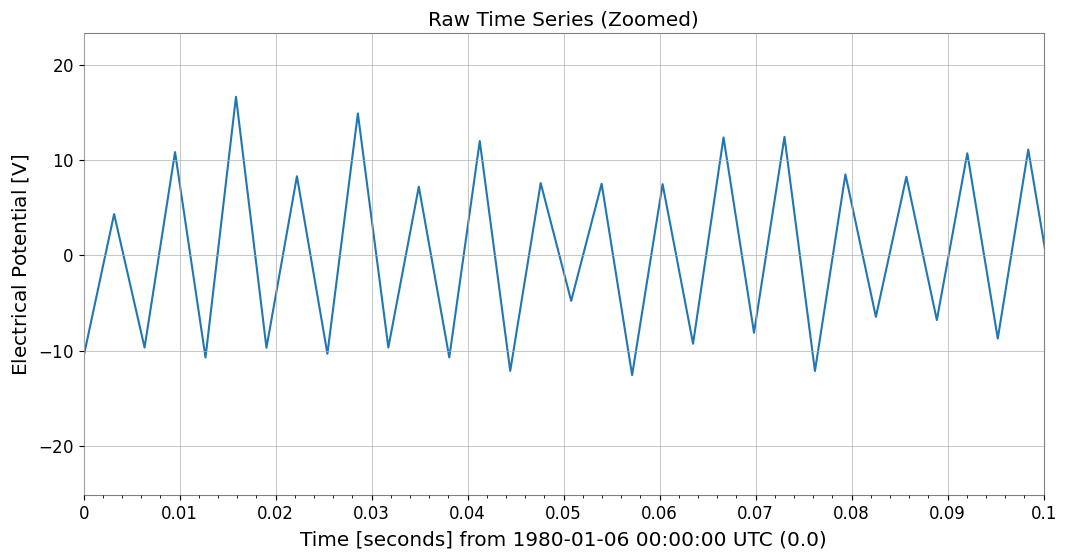

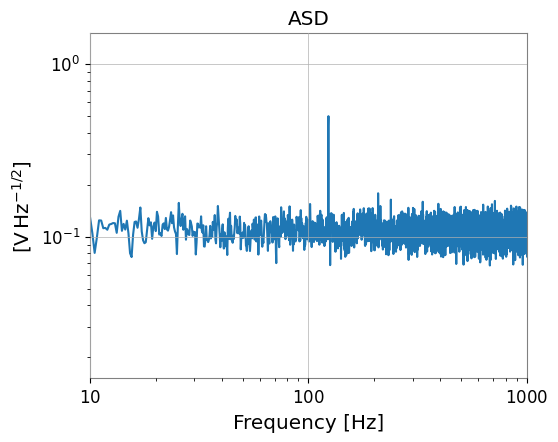

In [3]:
plot = ts.plot()
plot.gca().set_xlim(0, 0.1)
plot.gca().set_title("Raw Time Series (Zoomed)")
plt.show()

asd = ts.asd(fftlength=4, method="welch")
plot = asd.plot()
plot.gca().set_xlim(10, 1000)
plot.gca().set_yscale("log")
plot.gca().set_title("ASD")
plt.show()


## 2. Filter and fit the recovered signal

The band-pass is chosen to keep the injected line while rejecting unrelated broadband power. Making the band too narrow or too wide would respectively distort the tone or let too much noise back in.

- **Related API**: [Time Series API](../../reference/api/timeseries.rst), [Fitting API](../../reference/api/fitting.rst)
- **Related theory**: [Validated Algorithms](../validated_algorithms.md)

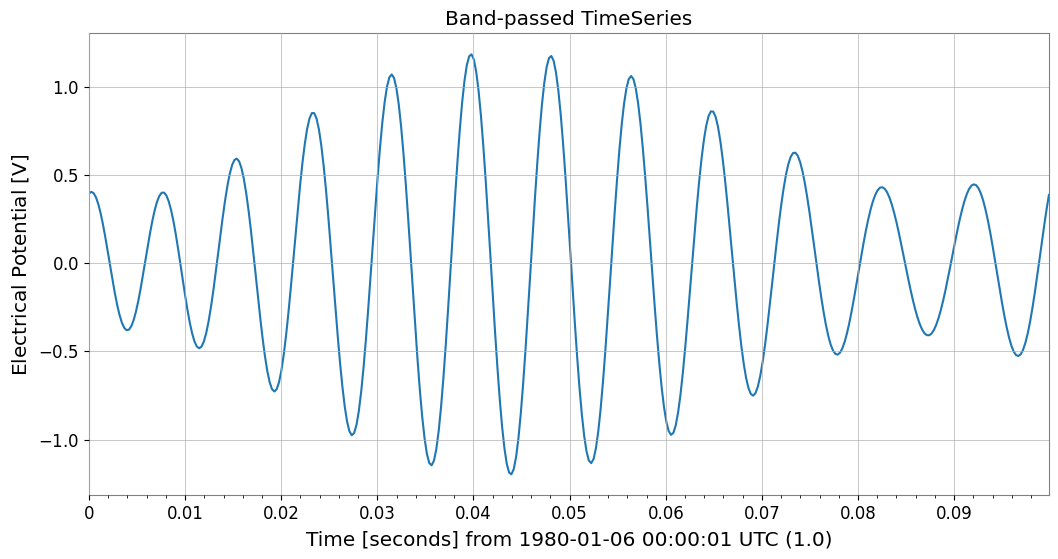

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 3.21e+05 (χ²/ndof = 794.5) │              Nfcn = 485              │
│ EDM = 9.32e-07 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│     SOME parameters at limit     │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬────────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬────

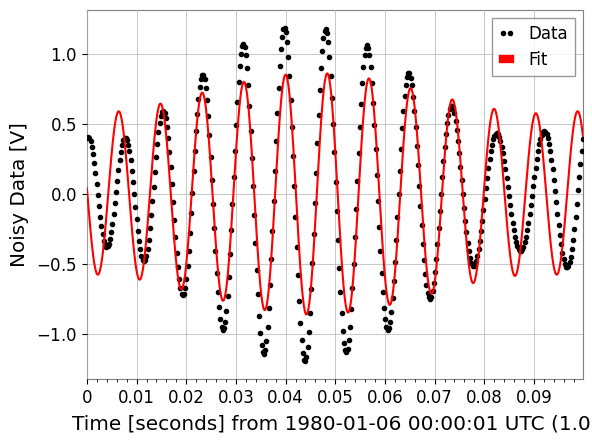

In [4]:
# Keep the band around the detected line so the fit sees the signal-dominated portion of the data.
filtered_ts = ts.bandpass(110, 130).crop(1, 1.1)

plot = filtered_ts.plot()
plot.gca().set_title("Band-passed TimeSeries")
plt.show()

def sine_model(t, amp, freq, phase, amp2, freq2, phase2):
    return amp * np.sin(2 * np.pi * freq * t + phase) * (1 + amp2 * np.sin(2 * np.pi * freq2 * t + phase2))

p0 = {"amp": 0.5, "freq": 123, "phase": 0, "amp2": 0.05, "freq2": 10, "phase2": 0}
limits = {"freq": (110, 130), "amp": (0.1, 5), "amp2": (0, 0.2), "freq2": (0, 50)}
result = filtered_ts.fit(sine_model, p0=p0, limits=limits, sigma=0.01)
print(result)
result.plot()
plt.show()
